In [8]:

import torch
import numpy as np
import d4rl
import pickle
from tqdm import tqdm
import argparse
import os
import gym
import matplotlib.pyplot as plt
from common.normalizer import StandardNormalizer


In [9]:

env_name = "hopper-expert-v0"
env = gym.make(env_name)
dataset = d4rl.qlearning_dataset(env)
env.reset()
data_buffer = {
            'observations': [],
            'actions': [],
            'rewards': [],
            'terminals': [],
            'next_observations': []
        }
# dataset = {key: dataset[key][:51] for key in dataset.keys()}
obs_normalizer = StandardNormalizer()
act_normalizer = StandardNormalizer()
obs_normalizer.update(dataset['observations'])
act_normalizer.update(dataset["actions"])

dataset['observations'] = obs_normalizer.transform(dataset['observations'])
dataset['actions']  = act_normalizer.transform(dataset["actions"])

dataset['next_observations'] = obs_normalizer.transform(dataset['next_observations'])

load datafile: 100%|██████████| 5/5 [00:00<00:00, 10.01it/s]


In [91]:
dataset['observations'].mean(0), dataset['actions'].mean(0), dataset['observations'].std(0), dataset['actions'].std(0), 

(array([ 8.45718040e-05,  7.30412981e-07,  4.36066459e-04,  5.12499607e-04,
         7.06836768e-06, -2.14459621e-04, -4.69006109e-08, -1.38449601e-08,
         1.41532260e-07, -1.30731532e-10, -1.34249058e-07]),
 array([ 4.81091198e-07, -9.43965957e-07,  1.09816712e-05]),
 array([1.0001599 , 1.00017677, 1.00025669, 1.00020088, 0.99997146,
        1.00038549, 1.00019579, 1.00038934, 1.00033828, 1.00041807,
        1.00019077]),
 array([1.00022172, 1.00016515, 0.99998518]))

In [92]:
dataset['actions'].std(0), dataset['actions'].mean(0)

(array([1.00022172, 1.00016515, 0.99998518]),
 array([ 4.81091198e-07, -9.43965957e-07,  1.09816712e-05]))

In [93]:
dataset['next_observations'].std(0), dataset['next_observations'].mean(0)

(array([1.00039876, 1.00069226, 0.99796659, 1.00012443, 1.0002956 ,
        0.99283642, 1.00100559, 1.00146994, 1.00093413, 1.0009012 ,
        1.00075667]),
 array([ 2.15182300e-05, -6.31671262e-04, -2.08862521e-03,  2.19340346e-04,
         3.86237349e-04,  4.17448389e-03, -1.35628905e-04,  5.40213589e-04,
         1.63735439e-04, -3.18549264e-04, -8.47728904e-04]))

In [11]:
def generate_noisy_data(d, env, nosie_scale = 0.1, batch_size = 50, num_samples = 50):
    noise_scale_state = d["observations"].std(0)*nosie_scale
    noise_scale_action = d["actions"].std(0)*nosie_scale

    total_batches = len(d['observations']) // batch_size
    

    #normalize the data and add the same noise
    for i in tqdm(range(total_batches)):
        state = d['observations'][i*batch_size:(i+1)*batch_size].copy()
        action = d['actions'][i*batch_size:(i+1)*batch_size].copy()
        
        #put random noise on state and action

        state_noise = np.random.normal(loc=np.zeros(noise_scale_state.shape)[:, None], scale=np.abs(noise_scale_state[:, None]), size=(noise_scale_state.shape[0],num_samples))
        state += state_noise.transpose()
        action_noise = np.random.normal(loc=np.zeros(noise_scale_action.shape)[:, None], scale=np.abs(noise_scale_action[:, None]), size=(noise_scale_action.shape[0],num_samples))
        action += action_noise.transpose()

        data_buffer['observations'].append(state)
        data_buffer['actions'].append(action)

        #get next_observations terminals and rewards with action
        for j in range(state.shape[0]):
            next_observation, reward, terminated, _ = env.step(action[j])
            data_buffer['next_observations'].append([next_observation])
            data_buffer['rewards'].append([reward])
            data_buffer['terminals'].append([terminated])
            if terminated:
                env.reset()
    i = 0
    # last batch
    if total_batches*batch_size < len(d['observations']):
        state = d['observations'][total_batches*batch_size:].copy()
        action = d['actions'][total_batches*batch_size:].copy()
        # if i==0:
        #     print("Last batch state :", state[0])
        #     print("Last batch action:", action[0])
        
        state_noise = np.random.normal(loc=np.zeros(noise_scale_state.shape)[:, None], scale=np.abs(noise_scale_state[:, None]), size=(noise_scale_state.shape[0],state.shape[0]))
        state += state_noise.transpose()
        action_noise = np.random.normal(loc=np.zeros(noise_scale_action.shape)[:, None], scale=np.abs(noise_scale_action[:, None]), size=(noise_scale_action.shape[0],state.shape[0]))
        action += action_noise.transpose()
        # if i==0:
        #     print("Last batch state :", state[0])
        #     print("Last batch action:", action[0])

        data_buffer['observations'].append(state)
        data_buffer['actions'].append(action)

        for j in range(state.shape[0]):
            next_observation, reward, terminated, _ = env.step(action[j])
            data_buffer['next_observations'].append([next_observation])
            data_buffer['rewards'].append([reward])
            data_buffer['terminals'].append([terminated])
            if terminated:
                env.reset()
    
    dataset_final = {
                key: np.concatenate(data_buffer[key], axis=0)
                for key in data_buffer.keys()
            }

    dataset_final['next_observations'] = dataset_final['next_observations'].reshape(d['next_observations'].shape)
    
    return dataset_final
    

In [12]:
nosie_scale= 0.5
# diti  = {key: dataset[key][:51] for key in dataset.keys()}
dataset_final = generate_noisy_data(dataset, env, nosie_scale = nosie_scale)


100%|██████████| 19980/19980 [02:41<00:00, 124.05it/s]


In [98]:
# dataa = dataset_final['next_observations'].copy()
# dataa = obs_normalizer.transform(dataa)
# dataa.max(), dataa.min(), dataa.mean(), dataa.std()

(9.13604262443399, -10.195673647274123, -0.4839057623642662, 1.737154404673293)

In [96]:
dataset_final['observations'].max(), dataset_final['observations'].min(), dataset_final['observations'].mean(), dataset_final['observations'].std(), 

(5.138804115165134,
 -6.11053902487203,
 6.481462352124411e-05,
 1.0014793135229074)

In [99]:
dataset_final['next_observations'].max(), dataset_final['next_observations'].min(), dataset_final['next_observations'].mean(), dataset_final['next_observations'].std()

(10.0, -10.0, -0.21159647901119505, 2.1609927884366313)

In [100]:
with open(f"/abiomed/intermediate_data_d4rl/{env_name}_noisy_{nosie_scale}.pkl", "wb") as f:
    pickle.dump(dataset_final, f)

In [13]:
def plot_features(data, data_noisy, title = ''):
    #plot histograms of all features in data
    num_features = data.shape[1]
    num_rows = int(np.ceil(num_features / 3))
    fig, axs = plt.subplots(num_rows, 3, figsize=(15, num_rows * 3))
    axs = axs.flatten()
    for i in range(num_features):
        axs[i].hist(data_noisy[:, i], bins=100, alpha=0.7, color='orange', label ="noisy")
        axs[i].hist(data[:, i], bins=100, alpha=0.7, color='blue', label = "expert")
        
        axs[i].set_title(f'Feature {i}')
        axs[i].set_xlabel('Value')
        axs[i].set_ylabel('Frequency')
        axs[i].legend()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [7]:
dataset['observations'].mean(), dataset['observations'].std(), dataset_final['observations'].mean(), dataset_final['observations'].std()

(7.512940328600234e-05,
 1.0002439788135922,
 0.00013490772839625025,
 1.0052039688727432)

In [8]:
dataset['next_observations'].mean(), dataset['next_observations'].std(), dataset_final['next_observations'].mean(), dataset_final['next_observations'].std()

(0.31703562, 2.2834024, -79.5774481092633, 299.2097112641482)

In [9]:
dataset['actions'].mean(), dataset['actions'].std(), dataset_final['actions'].mean(), dataset_final['actions'].std()

(3.5062654959740986e-06,
 1.0001240215468568,
 -3.2788638585934754e-05,
 1.0051521673508865)

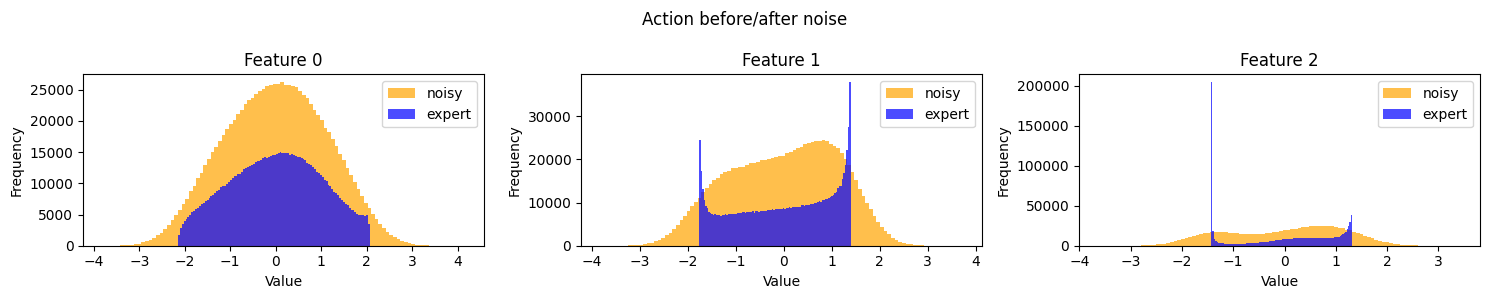

In [14]:
plot_features(dataset['actions'], dataset_final['actions'], title = "Action before/after noise")

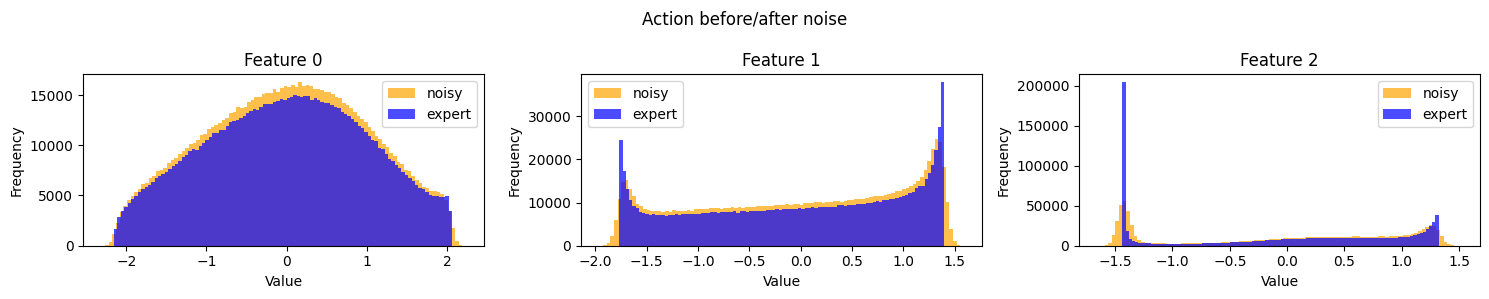

In [68]:
plot_features(dataset['actions'], dataset_final['actions'], title = "Action before/after noise")

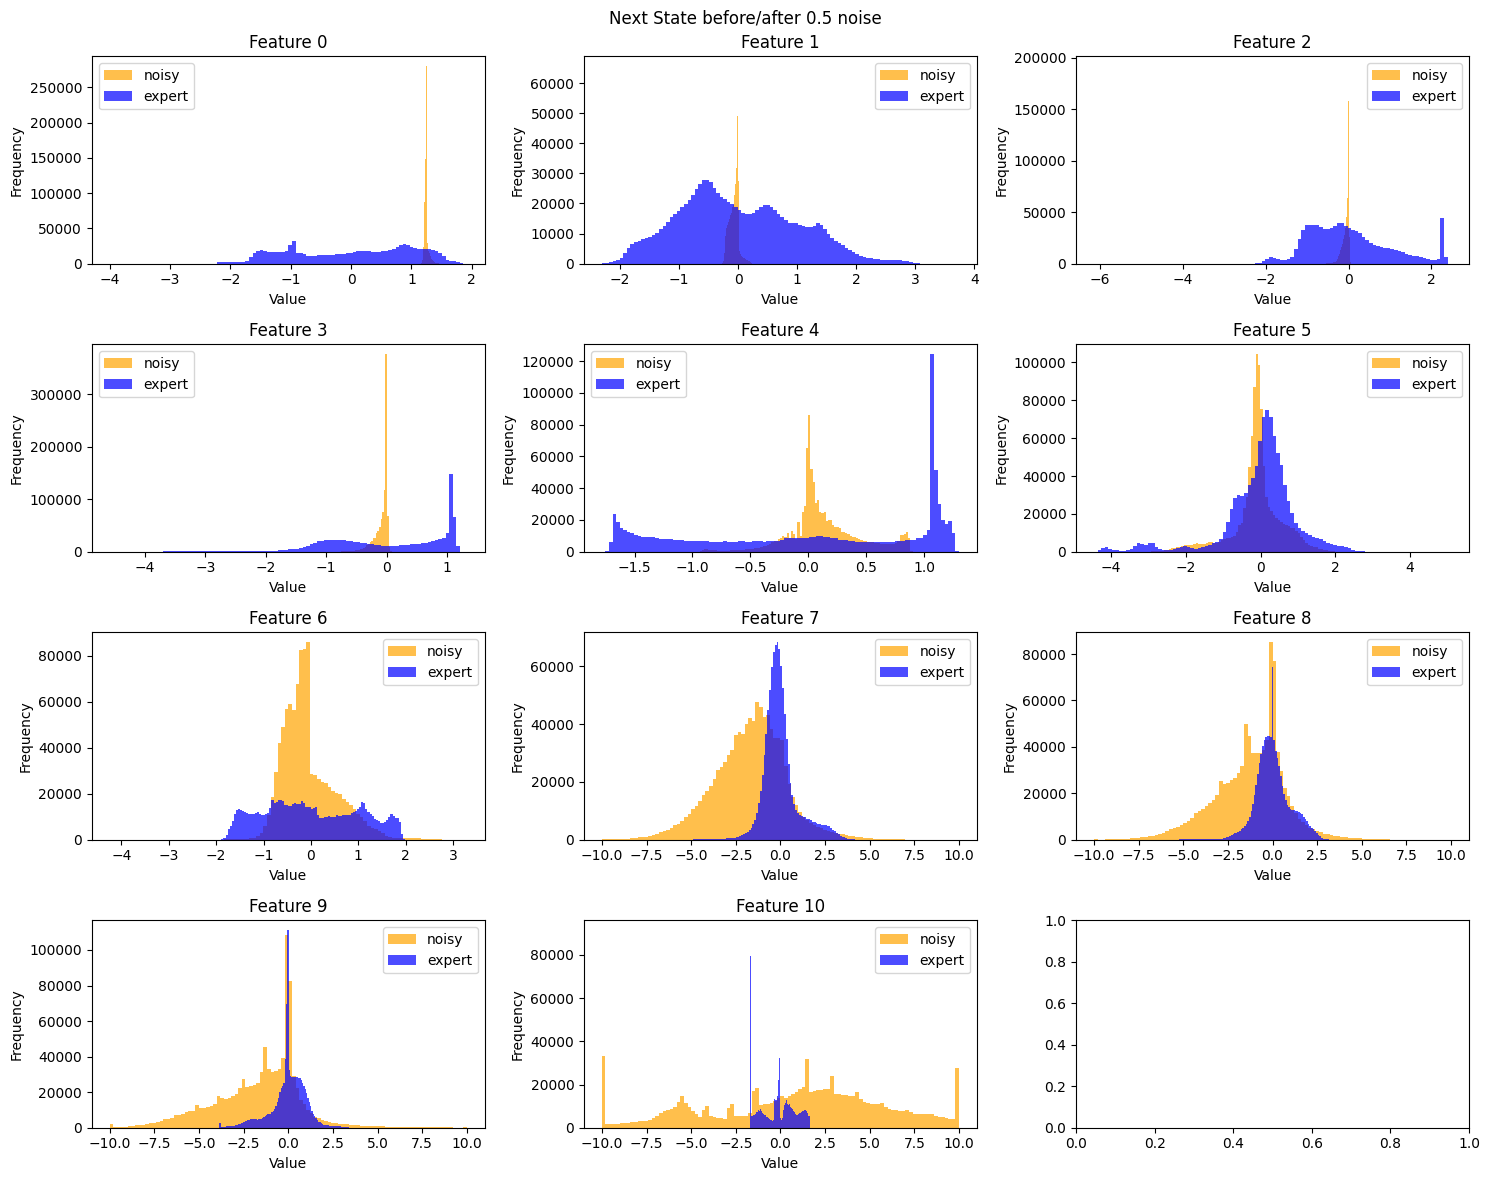

In [15]:
plot_features(dataset['next_observations'], dataset_final['next_observations'], title= "Next State before/after 0.5 noise")

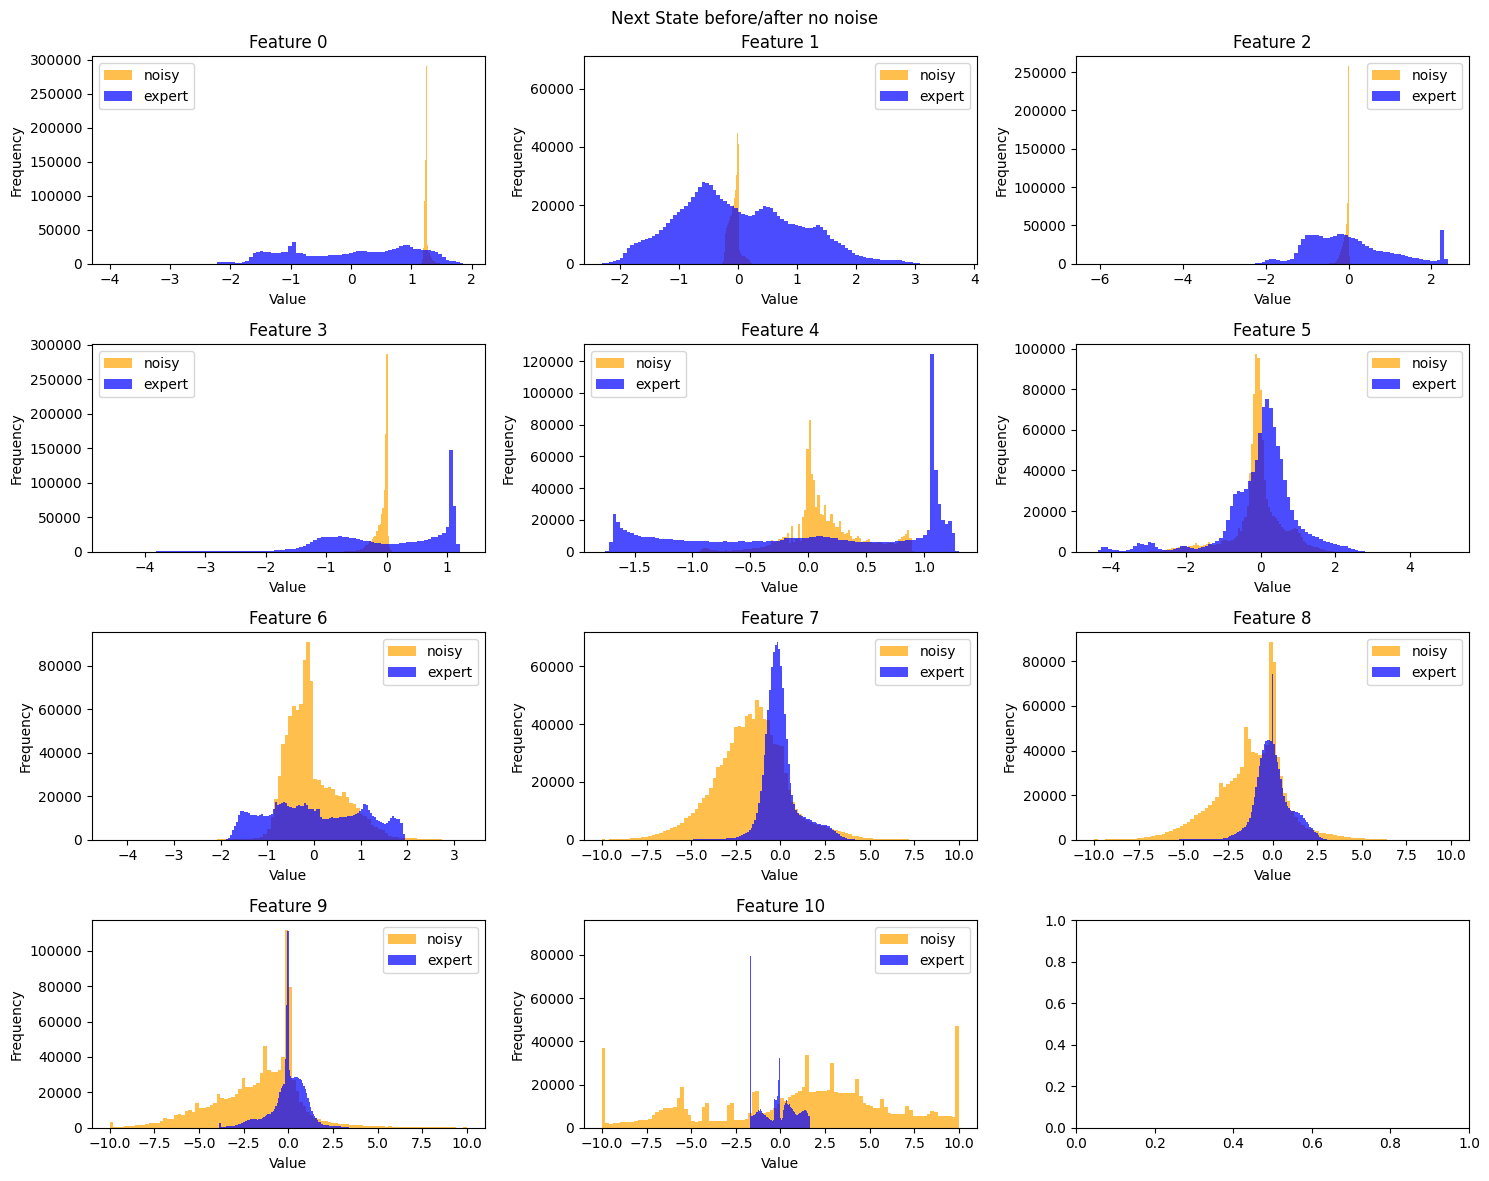

In [7]:
plot_features(dataset['next_observations'], dataset_final['next_observations'], title= "Next State before/after no noise")

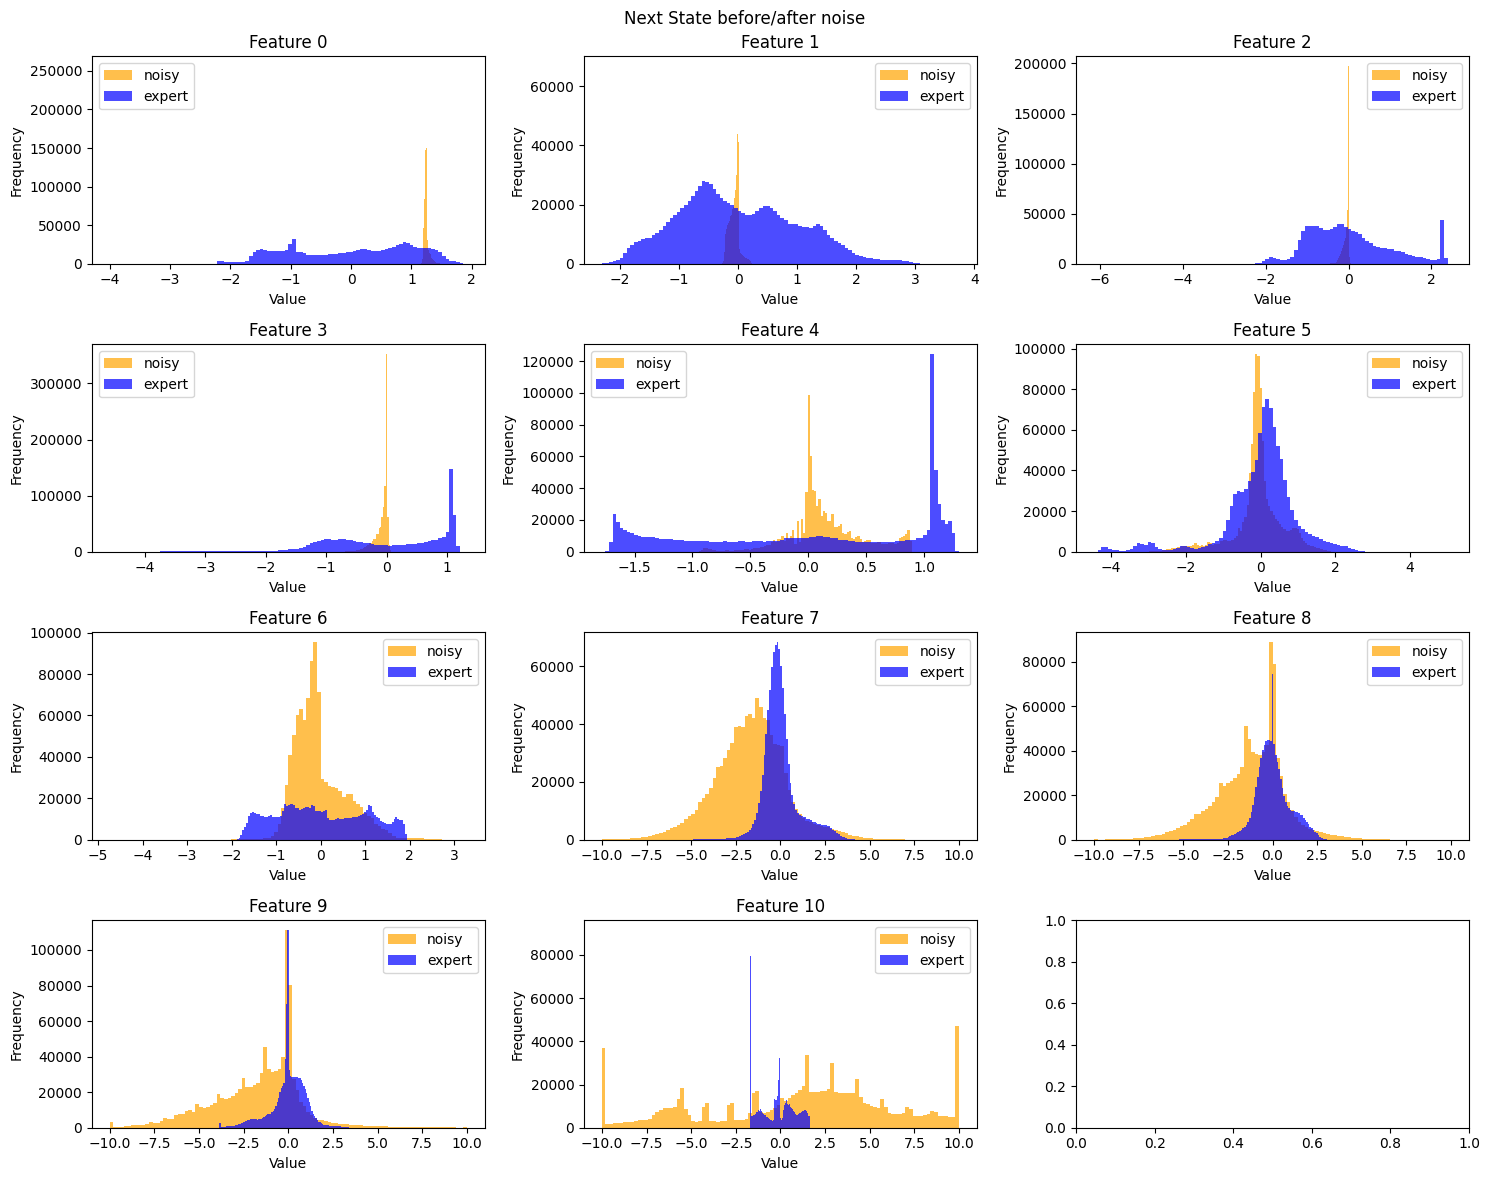

In [69]:
plot_features(dataset['next_observations'], dataset_final['next_observations'], title= "Next State before/after noise")

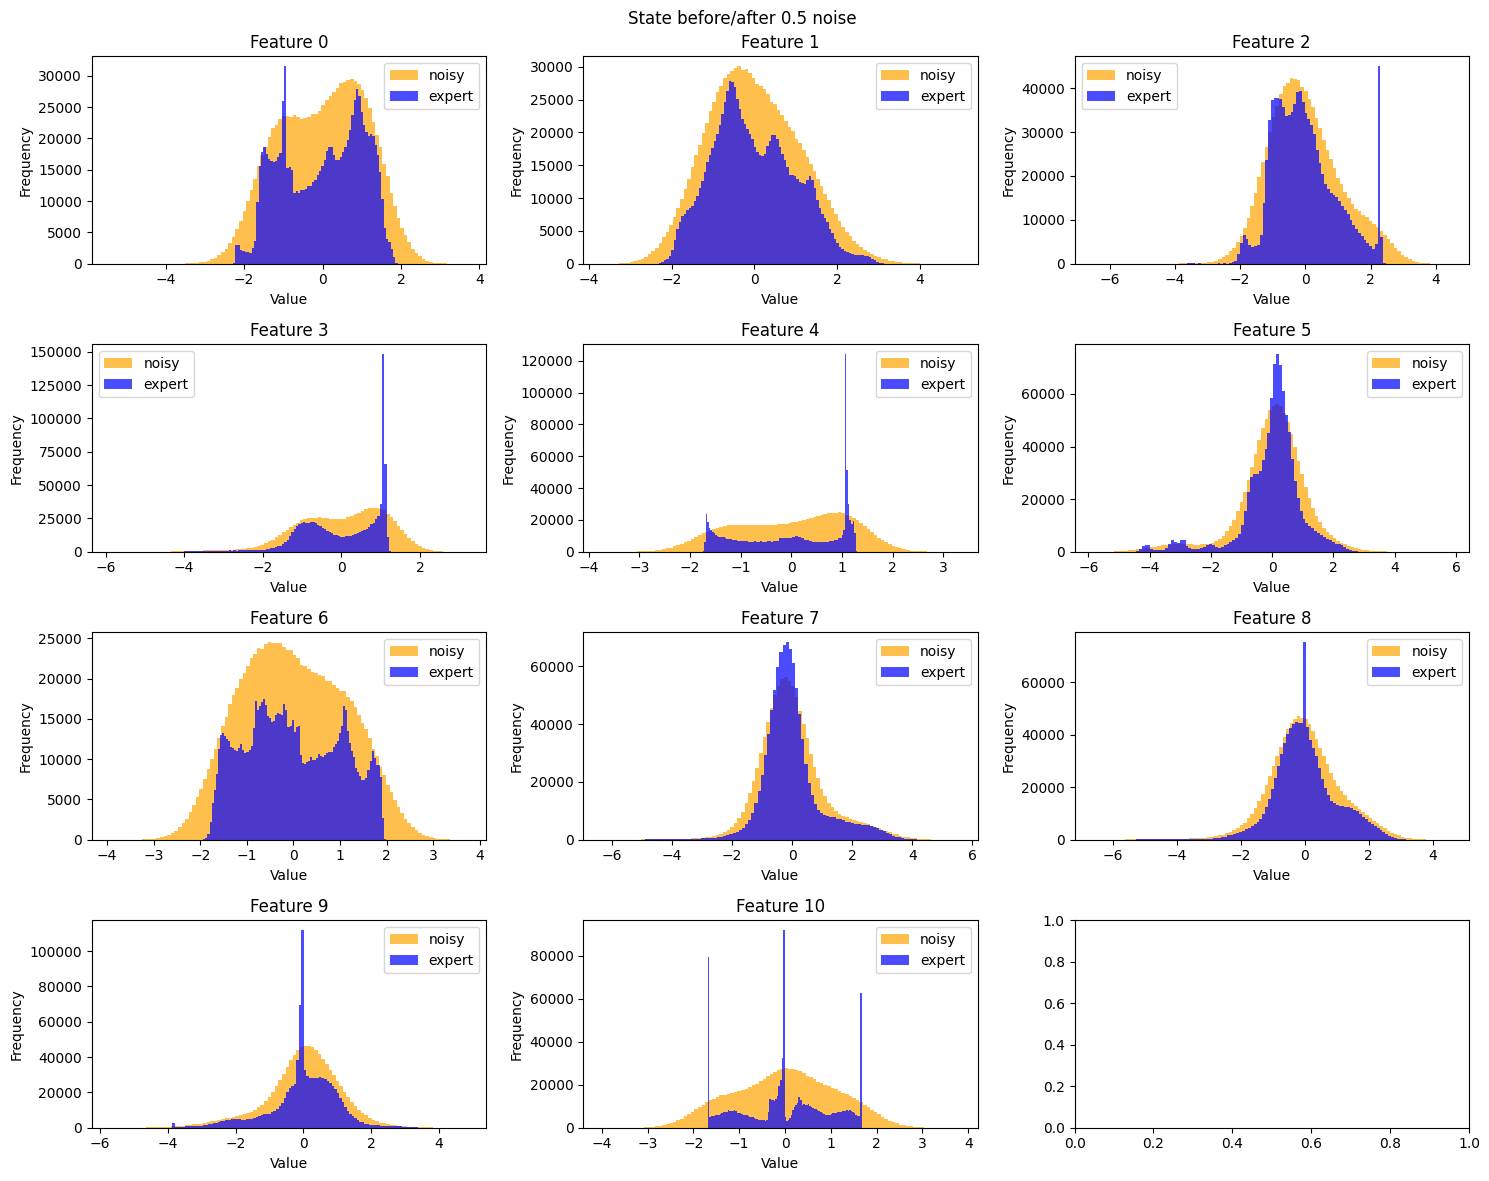

In [17]:
plot_features(dataset['observations'], dataset_final['observations'], title= 'State before/after 0.5 noise ')

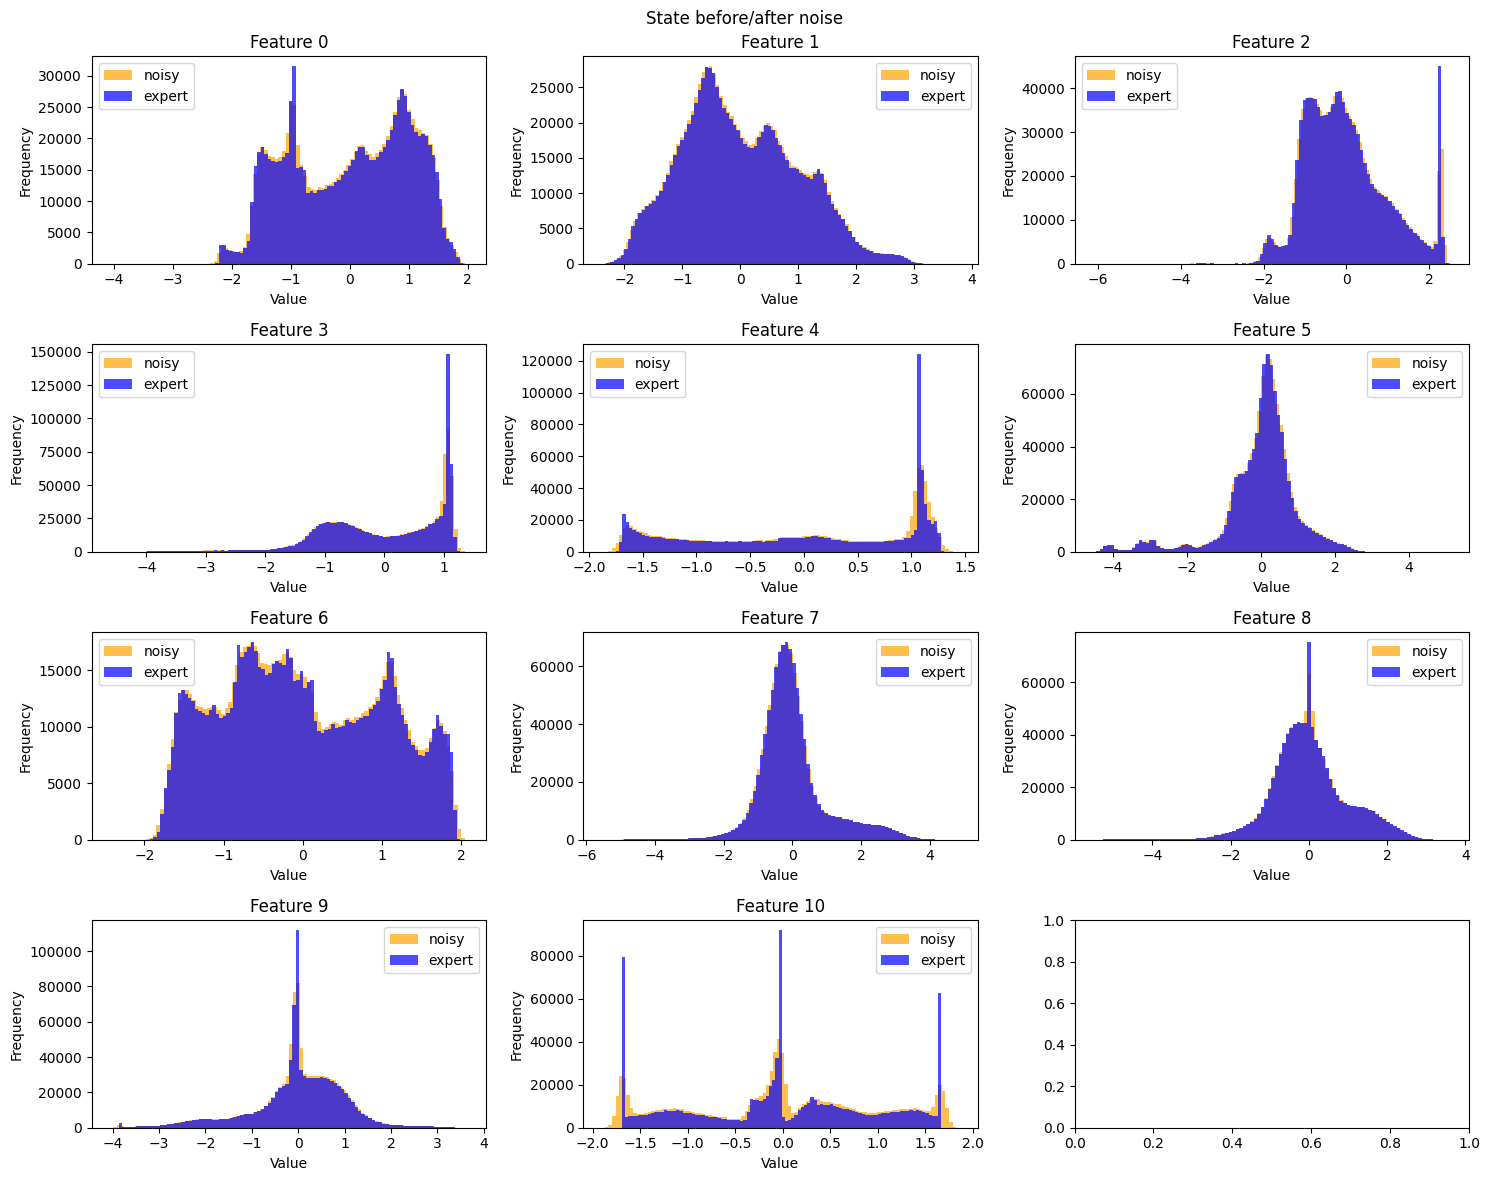

In [70]:
plot_features(dataset['observations'], dataset_final['observations'], title= 'State before/after noise')